# TUGAS INDIVIDUAL PRA-UTS
## 1. Identitas

* **Nama:** Mohamad Trio Solehudin
* **NIM:** 10122357
* **Kelas:** IF-2
* **Judul Tugas:** Analisis Rekayasa Fitur: Fokus Scaling & Encoding pada Metadata Gambar Dataset Sampah

## 2. Deskripsi Dataset

Dataset yang digunakan merupakan dataset kelompok (Tugas 1) yang berisikan gambar berbagai jenis sampah. Untuk keperluan rekayasa fitur dasar (Pra-UTS) ini, informasi dari gambar tersebut diekstrak menjadi data tabular berupa metadata gambar.

* **Sumber dataset:** Dikumpulkan secara manual dari Google Images, kemudian diedit dan dianotasi ke dalam folder berdasarkan kategori kelas.
* **Jumlah data:** Total 1.000 data gambar, terbagi seimbang menjadi 5 kelas (Kaca, Kardus, Kertas, Logam, Plastik) dengan masing-masing 200 data.
* **Jumlah fitur:** 5 fitur utama hasil ekstraksi awal (Nama File, Kategori, Ukuran_KB, Lebar_Pixel, Tinggi_Pixel).
* **Tipe data:** Tabular (Kategorikal untuk kelas/label, Numerikal kontinu untuk ukuran dan dimensi gambar).
* **Tujuan analisis:** Melakukan prapemrosesan data mentah (khususnya *Scaling* pada fitur dimensi/ukuran dan *Encoding* pada label kelas) agar rentang nilai fitur menjadi seragam.

## 3. Import Library

Pada tahap ini dilakukan import beberapa library yang digunakan untuk proses analisis data, preprocessing, visualisasi, serta seleksi fitur. Pengaturan *random seed* juga dideklarasikan di awal agar *reproducible* (tetap sama jika dijalankan ulang).

In [ ]:
# Library untuk pengolahan data tabular
import pandas as pd
import numpy as np

# Library untuk membuat visualisasi grafis
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk mengakses folder dan membaca metadata file gambar
import os
from PIL import Image

# Library untuk proses Preprocessing (Scaling & Encoding)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Mengatur random seed agar hasil konsisten (reproducible)
np.random.seed(42)

## 4. Load Dataset

Dataset diunduh secara *repository* GitHub menggunakan perintah `git clone`. Setelah itu, dilakukan ekstraksi metadata dasar (Lebar, Tinggi, Ukuran File) dari gambar-gambar tersebut untuk diubah menjadi format data tabular (DataFrame).

In [ ]:
# Hapus folder lama jika sudah ada saat di jalankan ulang
!rm -rf dataset-klasifikasi-sampah

# Mengunduh dataset dari GitHub
!git clone -q https://github.com/MohamadTrio/dataset-klasifikasi-sampah.git

# Menentukan jalur folder dataset
dataset_path = '/content/dataset-klasifikasi-sampah/dataset_sampah'

# List untuk menyimpan metadata gambar
data_list = []

# Looping untuk membaca folder dan gambar
for kategori in os.listdir(dataset_path):
    kategori_path = os.path.join(dataset_path, kategori)

    if os.path.isdir(kategori_path) and kategori != '.git':
        for file_name in os.listdir(kategori_path):
            file_path = os.path.join(kategori_path, file_name)

            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img = Image.open(file_path)
                    lebar, tinggi = img.size
                    ukuran_kb = os.path.getsize(file_path) / 1024

                    data_list.append({
                        'Nama_File': file_name,
                        'Lebar_Pixel': lebar,
                        'Tinggi_Pixel': tinggi,
                        'Ukuran_KB': round(ukuran_kb, 2),
                        'Kategori': kategori
                    })
                except Exception as e:
                    pass

# Mengubah list menjadi DataFrame
df = pd.DataFrame(data_list)

print(f"Total data gambar yang berhasil diekstrak: {len(df)}")
print("Berikut adalah 5 contoh data acak dari keseluruhan dataset:")

# Melihat 5 data acak
display(df.sample(5, random_state=42))

Total data gambar yang berhasil diekstrak: 1000
Berikut adalah 5 contoh data acak dari keseluruhan dataset:


,Nama_File,Lebar_Pixel,Tinggi_Pixel,Ukuran_KB,Kategori
521,IF_10_Kelompok_3_Gambar_Plastik_124.jpg,183,276,5.43,plastik
737,IF_10_Kelompok_3_Gambar_Kaca_18.jpg,225,225,3.76,kaca
740,IF_10_Kelompok_3_Gambar_Kaca_42.jpg,225,225,1.50,kaca
660,IF_10_Kelompok_3_Gambar_Kaca_6.jpg,225,225,3.87,kaca
411,IF_10_Kelompok_3_Gambar_Plastik_107.jpg,294,171,6.75,plastik


## 5. Pemahaman Data

Tahap ini bertujuan untuk memahami karakteristik dasar dari dataset tabular hasil ekstraksi metadata gambar. Pengecekan yang dilakukan meliputi:
1. **Info Dataset & Shape:** Melihat dimensi baris dan kolom serta tipe data masing-masing fitur.
2. **Statistik Dasar:** Melihat rentang nilai (min, max, rata-rata) pada fitur numerik (Lebar, Tinggi, Ukuran KB).
3. **Missing Value:** Memastikan apakah ada metadata gambar yang gagal terekstrak (kosong).
4. **Distribusi Kelas:** Memastikan pembagian jumlah gambar pada setiap kategori jenis sampah.

In [ ]:
# 1. Menampilkan Shape dan Info Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nama_File     1000 non-null   object 
 1   Lebar_Pixel   1000 non-null   int64  
 2   Tinggi_Pixel  1000 non-null   int64  
 3   Ukuran_KB     1000 non-null   float64
 4   Kategori      1000 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 39.2+ KB


In [ ]:
# 2. Menampilkan Statistik (hanya untuk kolom angka)
display(df.describe())

,Lebar_Pixel,Tinggi_Pixel,Ukuran_KB
count,1000.000000,1000.000000,1000.000000
mean,247.601000,222.399000,13.517400
std,76.281273,57.732997,32.027653
min,98.000000,127.000000,1.370000
25%,225.000000,192.000000,3.320000
50%,225.000000,225.000000,4.435000
75%,262.000000,225.000000,6.662500
max,1030.000000,773.000000,299.890000


In [ ]:
# 3. Pengecekan Missing Value
print(df.isnull().sum())

Nama_File       0
Lebar_Pixel     0
Tinggi_Pixel    0
Ukuran_KB       0
Kategori        0
dtype: int64


In [ ]:
# 4. Distribusi Data (Jumlah gambar per kategori)
print(df['Kategori'].value_counts())

Kategori
logam      200
kertas     200
plastik    200
kaca       200
kardus     200
Name: count, dtype: int64


## 6. Preprocessing Data

Pada tahap ini, dilakukan dua teknik prapemrosesan:
1. **Label Encoding:** Mengubah kolom target `Kategori` yang bertipe teks/kategorikal (kaca, kardus, kertas, logam, plastik) menjadi representasi numerik (0, 1, 2, 3, 4) menggunakan `LabelEncoder`.
2. **Feature Scaling:** Menyamakan rentang skala pada fitur numerik (`Lebar_Pixel`, `Tinggi_Pixel`, `Ukuran_KB`) menggunakan `MinMaxScaler`. Berdasarkan hasil statistik dasar, fitur dimensi memiliki rentang hingga ribuan, sedangkan ukuran file hanya ratusan. *Scaling* dilakukan ke rentang 0-1 agar tidak ada fitur yang mendominasi fitur lain.

In [ ]:
# Inisialisasi
label_encoder = LabelEncoder()
scaler = MinMaxScaler()

# 1. Label Encoding pada kolom Kategori
# Membuat kolom baru 'Kategori_Encoded' agar data teks aslinya tidak hilang
df['Kategori_Encoded'] = label_encoder.fit_transform(df['Kategori'])

# Menampilkan mapping dari kelas teks ke angka
print("HASIL LABEL ENCODING")
mapping_kelas = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print(f"Mapping Kelas: {mapping_kelas}\n")

# 2. Feature Scaling pada kolom numerik
kolom_numerik = ['Lebar_Pixel', 'Tinggi_Pixel', 'Ukuran_KB']

for col in kolom_numerik:
    df[f'{col}_Scaled'] = scaler.fit_transform(df[[col]])

print("HASIL FEATURE SCALING (5 Data)")
# Menampilkan kolom sebelum dan sesudah preprocessing untuk perbandingan
kolom_tampil = ['Nama_File', 'Kategori', 'Kategori_Encoded',
                'Ukuran_KB', 'Ukuran_KB_Scaled',
                'Lebar_Pixel', 'Lebar_Pixel_Scaled',
                'Tinggi_Pixel', 'Tinggi_Pixel_Scaled']
display(df[kolom_tampil].head())

HASIL LABEL ENCODING
Mapping Kelas: {'kaca': 0, 'kardus': 1, 'kertas': 2, 'logam': 3, 'plastik': 4}

HASIL FEATURE SCALING (5 Data)


,Nama_File,Kategori,Kategori_Encoded,Ukuran_KB,Ukuran_KB_Scaled,Lebar_Pixel,Lebar_Pixel_Scaled,Tinggi_Pixel,Tinggi_Pixel_Scaled
0,IF_10_Kelompok_3_Gambar_Logam_88.jpg,logam,3,8.06,0.022411,301,0.217811,167,0.061920
1,IF_10_Kelompok_3_Gambar_Logam_97.jpg,logam,3,5.10,0.012495,225,0.136266,225,0.151703
2,IF_10_Kelompok_3_Gambar_Logam_118.jpg,logam,3,2.52,0.003852,279,0.194206,180,0.082043
3,IF_10_Kelompok_3_Gambar_Logam_95.jpg,logam,3,9.18,0.026162,264,0.178112,191,0.099071
4,IF_10_Kelompok_3_Gambar_Logam_89.jpg,logam,3,4.89,0.011792,225,0.136266,225,0.151703


## 7. Rekayasa Fitur

Rekayasa fitur dilakukan untuk mengekstraksi informasi tersembunyi dari metadata dimensi gambar.

Fitur yang dibuat adalah **Aspect_Ratio** (Rasio Aspek).
* **Cara pembuatan:** Dihitung dengan membagi `Lebar_Pixel` dengan `Tinggi_Pixel`.
* **Alasan pembuatan:** Dimensi tunggal (lebar saja atau tinggi saja) terkadang tidak cukup representatif. Rasio aspek dapat merepresentasikan orientasi atau bentuk objek di dalam gambar (misalnya, apakah objek botol plastik cenderung vertikal/*portrait*, atau kardus cenderung persegi).
* **Manfaat:** Memberikan petunjuk tambahan bagi model klasifikasi terkait bentuk fisik dari masing-masing kategori sampah.

*Catatan: Setelah fitur ini dibuat, fitur tersebut juga langsung dinormalisasi (Scaled) agar selaras dengan fitur lainnya.*

In [ ]:
# 1. Pembuatan Fitur Baru: Aspect Ratio
df['Aspect_Ratio'] = df['Lebar_Pixel'] / df['Tinggi_Pixel']

# 2. Scaling pada fitur baru agar seragam (rentang 0-1)
df['Aspect_Ratio_Scaled'] = scaler.fit_transform(df[['Aspect_Ratio']])

# Menampilkan hasil pembuatan fitur
print("HASIL PEMBUATAN FITUR ASPECT RATIO")
kolom_fitur_baru = ['Nama_File', 'Kategori', 'Lebar_Pixel', 'Tinggi_Pixel', 'Aspect_Ratio', 'Aspect_Ratio_Scaled']
display(df[kolom_fitur_baru].head())

HASIL PEMBUATAN FITUR ASPECT RATIO


,Nama_File,Kategori,Lebar_Pixel,Tinggi_Pixel,Aspect_Ratio,Aspect_Ratio_Scaled
0,IF_10_Kelompok_3_Gambar_Logam_88.jpg,logam,301,167,1.802395,0.512075
1,IF_10_Kelompok_3_Gambar_Logam_97.jpg,logam,225,225,1.000000,0.212719
2,IF_10_Kelompok_3_Gambar_Logam_118.jpg,logam,279,180,1.550000,0.417912
3,IF_10_Kelompok_3_Gambar_Logam_95.jpg,logam,264,191,1.382199,0.355309
4,IF_10_Kelompok_3_Gambar_Logam_89.jpg,logam,225,225,1.000000,0.212719


## 8. Visualisasi Fitur

Tahap ini memvisualisasikan fitur untuk mendapatkan *insight* mengenai distribusi dan hubungannya dengan kategori data.

**1. Visualisasi 1: Histogram**
* **Interpretasi:** Grafik ini membandingkan distribusi fitur `Ukuran_KB` sebelum dan sesudah *MinMaxScaler*. Dapat dilihat bahwa bentuk kurva distribusinya (kemiringannya) tetap sama persis, namun sumbu-X (rentang nilai) berubah drastis dari ratusan (0-300) menjadi hanya rentang 0 hingga 1. Hal ini membuktikan bahwa *scaling* berhasil merapatkan data tanpa merusak informasi aslinya.

**2. Visualisasi 2: Boxplot (Sebaran Aspect Ratio per Kategori)**
* **Interpretasi:** Boxplot ini menunjukkan variasi bentuk gambar (orientasi) pada masing-masing kategori sampah. Nilai rasio 1.0 menandakan gambar berbentuk persegi. Titik-titik hitam di luar garis kumis (*whiskers*) merupakan *outlier*, yang menandakan adanya gambar yang bentuknya sangat memanjang secara ekstrem (baik *landscape* maupun *portrait*) dibandingkan rata-rata gambar di kategorinya.

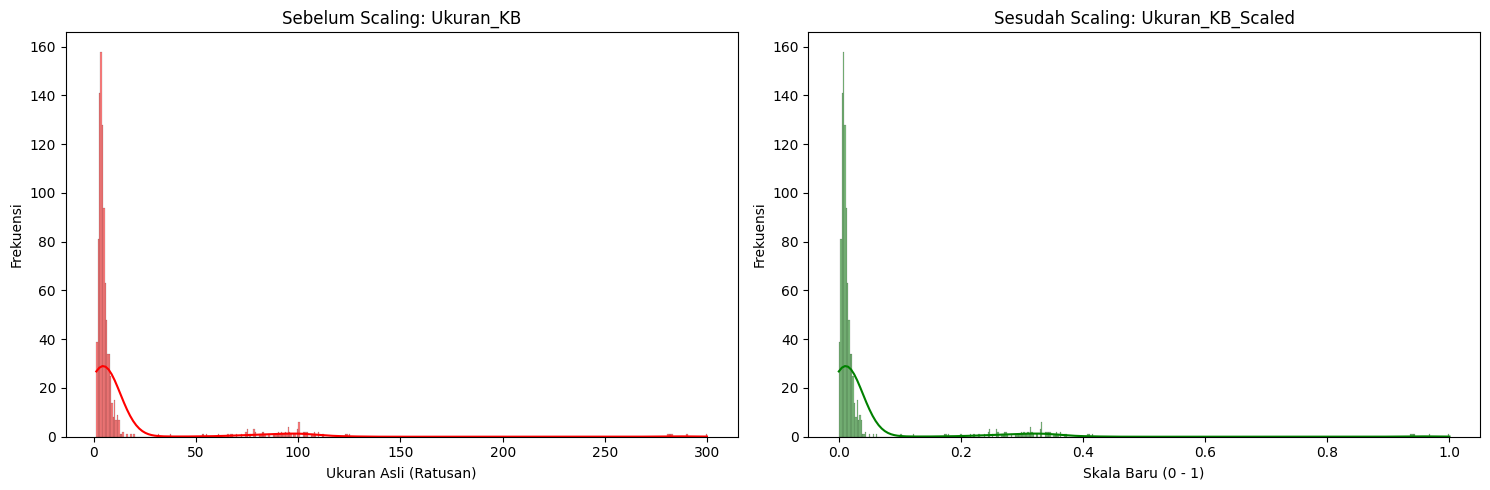

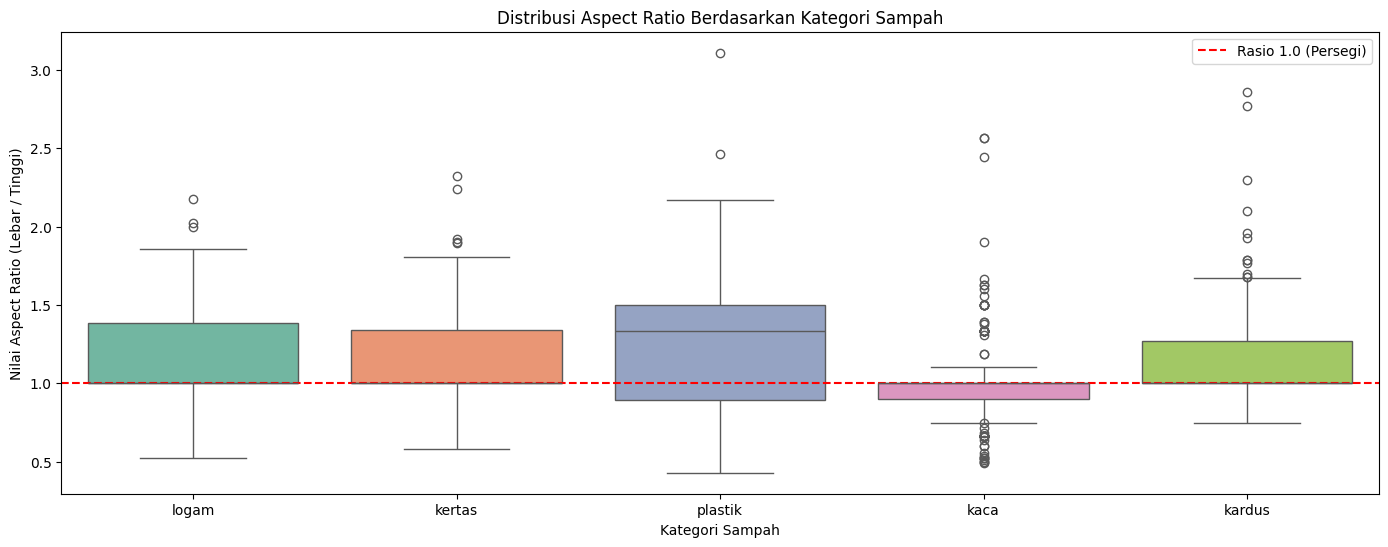

In [ ]:
# Mengatur ukuran kanvas secara keseluruhan
plt.figure(figsize=(15, 5))

# ==========================================
# VISUALISASI 1: HISTOGRAM (Sebelum vs Sesudah Scaling)
# ==========================================
plt.subplot(1, 2, 1)
sns.histplot(df['Ukuran_KB'], kde=True, color='red')
plt.title('Sebelum Scaling: Ukuran_KB')
plt.xlabel('Ukuran Asli (Ratusan)')
plt.ylabel('Frekuensi')

plt.subplot(1, 2, 2)
sns.histplot(df['Ukuran_KB_Scaled'], kde=True, color='green')
plt.title('Sesudah Scaling: Ukuran_KB_Scaled')
plt.xlabel('Skala Baru (0 - 1)')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# ==========================================
# VISUALISASI 2: BOXPLOT (Aspect Ratio per Kategori)
# ==========================================
plt.figure(figsize=(17, 6))
# Ubah baris kode sebelumnya menjadi ini:
sns.boxplot(x='Kategori', y='Aspect_Ratio', data=df, hue='Kategori', palette='Set2', legend=False)
plt.title('Distribusi Aspect Ratio Berdasarkan Kategori Sampah')
plt.xlabel('Kategori Sampah')
plt.ylabel('Nilai Aspect Ratio (Lebar / Tinggi)')
plt.axhline(y=1.0, color='r', linestyle='--', label='Rasio 1.0 (Persegi)')
plt.legend()
plt.show()

## 9. Seleksi Fitur

Metode seleksi fitur yang digunakan adalah **Korelasi (Heatmap)**. Tujuannya adalah untuk mendeteksi kondisi dimana terdapat dua atau lebih fitur yang memiliki korelasi sangat kuat sehingga informasinya menjadi redundan.

**Keputusan Seleksi:**
* **Fitur yang dievaluasi:** `Lebar_Pixel_Scaled`, `Tinggi_Pixel_Scaled`, `Ukuran_KB_Scaled`, `Aspect_Ratio_Scaled`.
* **Fitur yang dibuang:**
  1. `Tinggi_Pixel_Scaled`: Dibuang untuk menghindari redundansi, karena informasi tinggi dan lebar sudah terwakili dengan baik oleh fitur `Aspect_Ratio_Scaled`.
  2. Semua fitur mentah yang belum di-*scaling* dan di-*encoding* (`Nama_File`, `Kategori`, `Lebar_Pixel`, `Tinggi_Pixel`, `Ukuran_KB`, `Aspect_Ratio`).
* **Fitur yang dipilih (dipertahankan):** `Kategori_Encoded` (sebagai target), `Lebar_Pixel_Scaled`, `Ukuran_KB_Scaled`, dan `Aspect_Ratio_Scaled`.

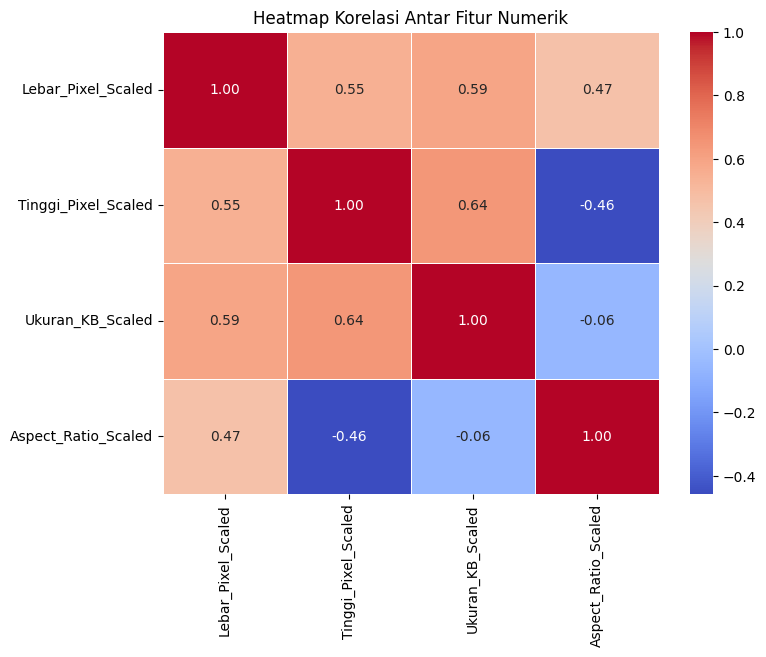

,Kategori_Encoded,Lebar_Pixel_Scaled,Ukuran_KB_Scaled,Aspect_Ratio_Scaled
0,3,0.217811,0.022411,0.512075
1,3,0.136266,0.012495,0.212719
2,3,0.194206,0.003852,0.417912
3,3,0.178112,0.026162,0.355309
4,3,0.136266,0.011792,0.212719


In [ ]:
# 1. Memilih fitur numerik yang sudah di-scaling untuk dicek korelasinya
fitur_evaluasi = ['Lebar_Pixel_Scaled', 'Tinggi_Pixel_Scaled', 'Ukuran_KB_Scaled', 'Aspect_Ratio_Scaled']
korelasi_matriks = df[fitur_evaluasi].corr()

# 2. Membuat Visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(korelasi_matriks, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

# 3. Proses Membuang Fitur (Drop Columns)
kolom_yang_dibuang = [
    'Tinggi_Pixel_Scaled','Nama_File', 'Kategori', 'Lebar_Pixel', 'Tinggi_Pixel', 'Ukuran_KB', 'Aspect_Ratio'
]

# Membuat DataFrame yang sudah bersih
df_final = df.drop(columns=kolom_yang_dibuang)

display(df_final.head())

## 10. Kesimpulan

Berdasarkan seluruh proses rekayasa fitur yang telah dilakukan pada metadata gambar dataset klasifikasi sampah, dapat disimpulkan bahwa:

1. **Keberhasilan Preprocessing (Fokus Utama):**
  * **Encoding:** Fitur target `Kategori` yang awalnya berupa teks telah berhasil dikonversi menjadi representasi numerik (0-4) menggunakan `LabelEncoder`.
   * **Scaling:** Terjadi ketimpangan rentang nilai yang sangat jauh antara dimensi piksel (ribuan) dan ukuran file (ratusan). Penggunaan `MinMaxScaler` terbukti berhasil meratakan seluruh fitur numerik ke dalam skala [0, 1] tanpa mengubah distribusi asli data, mencegah terjadinya bias skala pada model.
2. **Rekayasa Fitur Tambahan:** Telah berhasil diekstrak fitur baru yaitu `Aspect_Ratio` yang merepresentasikan proporsi orientasi gambar. Dari analisis visual (Boxplot), terdeteksi adanya *outlier* pada fitur ini. Namun, *outlier* sengaja dipertahankan karena penanganan pencilan (*outlier engineering*) merupakan domain fokus dari anggota kelompok lain, sekaligus membuktikan sensitivitas *scaler* terhadap nilai ekstrem.
3. **Seleksi Fitur:** Analisis *Heatmap* korelasi membuktikan adanya redundansi informasi (multikolinearitas) antara fitur tinggi, lebar, dan ukuran file. Oleh karena itu, fitur `Tinggi_Pixel_Scaled` dibuang, menyisakan 3 fitur prediktor utama (`Lebar_Pixel_Scaled`, `Ukuran_KB_Scaled`, `Aspect_Ratio_Scaled`) yang padat informasi dan siap digunakan untuk fase pemodelan *Machine Learning* selanjutnya.

---

### Deklarasi Penggunaan AI Tools
* **Tools yang digunakan:** Gemini
* **Tujuan Penggunaan:**
  * Membantu memahami sintaks Python untuk mengekstrak metadata dari folder gambar di GitHub.
  * Membantu memahami sintaks prapemrosesan data pada tahapan Feature Scaling dan Label Encoding.
  * Membantu melakukan debugging
  * Membantu memahami cara membaca grafik
